# Tarefa: Pré-processamento de Dados — Normalização, Transformação e Discretização

**Aluno:** Cauê Reis

**Disciplina:** Mineração de Dados

## Dataset Iris — Preparação de Dados para Algoritmos de Mineração

**Objetivo:** Transformar dados brutos em um formato otimizado para algoritmos de mineração, aplicando **normalização (Min-Max)**, **padronização (z-score)** e **discretização (pd.cut)** às medidas de flores do dataset Iris.

Todas as variáveis devem estar na mesma escala e alguns atributos devem ser convertidos para valores categóricos (discretos), conforme exigido por determinados algoritmos de mineração.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler, StandardScaler

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

### 1. Carregamento dos Dados

In [3]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
df['target'] = iris.target
df['Especie'] = df['target'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

display(df.head(10))

print(f'\nDimensoes: {df.shape[0]} amostras x {df.shape[1]-2} atributos')
print(f'Classes   : {list(iris.target_names)}')
print(f'\nDistribuicao das classes:')
print(df['Especie'].value_counts())

,sepal_length,sepal_width,petal_length,petal_width,target,Especie
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa
5,5.4,3.9,1.7,0.4,0,Setosa
6,4.6,3.4,1.4,0.3,0,Setosa
7,5.0,3.4,1.5,0.2,0,Setosa
8,4.4,2.9,1.4,0.2,0,Setosa
9,4.9,3.1,1.5,0.1,0,Setosa



Dimensoes: 150 amostras x 4 atributos
Classes   : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Distribuicao das classes:
Especie
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


### 2. Análise Exploratória — Estatísticas Descritivas

In [5]:
display(df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].describe().round(3))

,sepal_length,sepal_width,petal_length,petal_width
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


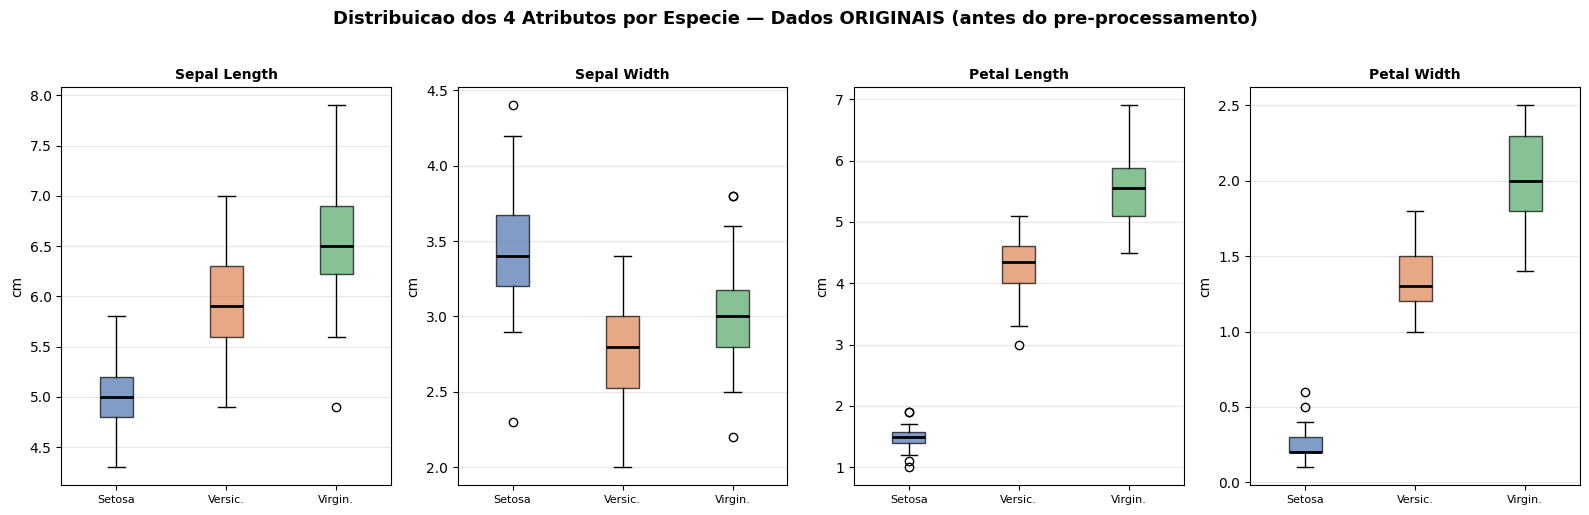

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

colunas_orig = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
nomes_exib   = ['Sepal Length (cm)', 'Sepal Width (cm)', 'Petal Length (cm)', 'Petal Width (cm)']
cores = {'Setosa': '#4C72B0', 'Versicolor': '#DD8452', 'Virginica': '#55A868'}

for ax, col, nome in zip(axes, colunas_orig, nomes_exib):
    grupos = [df[df['Especie'] == esp][col].values for esp in cores]
    bp = ax.boxplot(grupos, patch_artist=True)
    for patch, cor in zip(bp['boxes'], cores.values()):
        patch.set_facecolor(cor)
        patch.set_alpha(0.7)
    for median in bp['medians']:
        median.set(color='black', linewidth=2)
    ax.set_title(nome.replace(' (cm)', ''), fontsize=10, fontweight='bold')
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['Setosa', 'Versic.', 'Virgin.'], fontsize=8)
    ax.set_ylabel('cm')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribuicao dos 4 Atributos por Especie — Dados ORIGINAIS (antes do pre-processamento)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3. Normalização Min-Max

**Fórmula:**

$$x_{\text{norm}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

Garante que todos os valores fiquem **estritamente entre 0 e 1**, mapeando o mínimo para 0 e o máximo para 1. É sensível a outliers, pois usa os valores extremos da amostra.

In [8]:
scaler_minmax = MinMaxScaler()

df['sepal_length_norm'] = scaler_minmax.fit_transform(df[['sepal_length']])
df['sepal_width_norm']  = scaler_minmax.fit_transform(df[['sepal_width']])
df['petal_length_norm'] = scaler_minmax.fit_transform(df[['petal_length']])
df['petal_width_norm']  = scaler_minmax.fit_transform(df[['petal_width']])

cols_norm = ['sepal_length_norm', 'sepal_width_norm', 'petal_length_norm', 'petal_width_norm']
display(df[cols_norm].describe().round(4))
print('\n>>> Min deve ser 0.0000 e Max deve ser 1.0000 em todas as colunas')

,sepal_length_norm,sepal_width_norm,petal_length_norm,petal_width_norm
count,150.0000,150.0000,150.0000,150.0000
mean,0.4287,0.4406,0.4675,0.4581
std,0.2300,0.1816,0.2992,0.3176
min,0.0000,0.0000,0.0000,0.0000
25%,0.2222,0.3333,0.1017,0.0833
50%,0.4167,0.4167,0.5678,0.5000
75%,0.5833,0.5417,0.6949,0.7083
max,1.0000,1.0000,1.0000,1.0000



>>> Min deve ser 0.0000 e Max deve ser 1.0000 em todas as colunas


### 4. Padronização Z-score (StandardScaler)

**Fórmula:**

$$x_{\text{std}} = \frac{x - \mu}{\sigma}$$

Onde $\mu$ é a média e $\sigma$ é o desvio padrão. O resultado tem **média 0 e desvio padrão 1**, mas os valores **não ficam restritos ao intervalo [0, 1]** — podem ser negativos ou maiores que 1. É mais robusta a outliers que o Min-Max.

In [9]:
scaler_std = StandardScaler()

df['sepal_length_std'] = scaler_std.fit_transform(df[['sepal_length']])
df['sepal_width_std']  = scaler_std.fit_transform(df[['sepal_width']])
df['petal_length_std'] = scaler_std.fit_transform(df[['petal_length']])
df['petal_width_std']  = scaler_std.fit_transform(df[['petal_width']])

print('Verificacao pos-padronizacao Z-score:')
cols_std = ['sepal_length_std', 'sepal_width_std', 'petal_length_std', 'petal_width_std']
display(df[cols_std].describe().round(4))
print('\n>>> Media deve ser ~0 e Desvio Padrao deve ser ~1 em todas as colunas')
print('>>> Note: Min e Max NAO sao 0 e 1 — valores negativos sao esperados')

Verificacao pos-padronizacao Z-score:


,sepal_length_std,sepal_width_std,petal_length_std,petal_width_std
count,150.0000,150.0000,150.0000,150.0000
mean,-0.0000,-0.0000,-0.0000,-0.0000
std,1.0034,1.0034,1.0034,1.0034
min,-1.8700,-2.4339,-1.5676,-1.4471
25%,-0.9007,-0.5924,-1.2266,-1.1838
50%,-0.0525,-0.1320,0.3365,0.1325
75%,0.6745,0.5586,0.7628,0.7907
max,2.4920,3.0908,1.7858,1.7121



>>> Media deve ser ~0 e Desvio Padrao deve ser ~1 em todas as colunas
>>> Note: Min e Max NAO sao 0 e 1 — valores negativos sao esperados


### 5. Visualização Comparativa: Original × Min-Max × Z-score

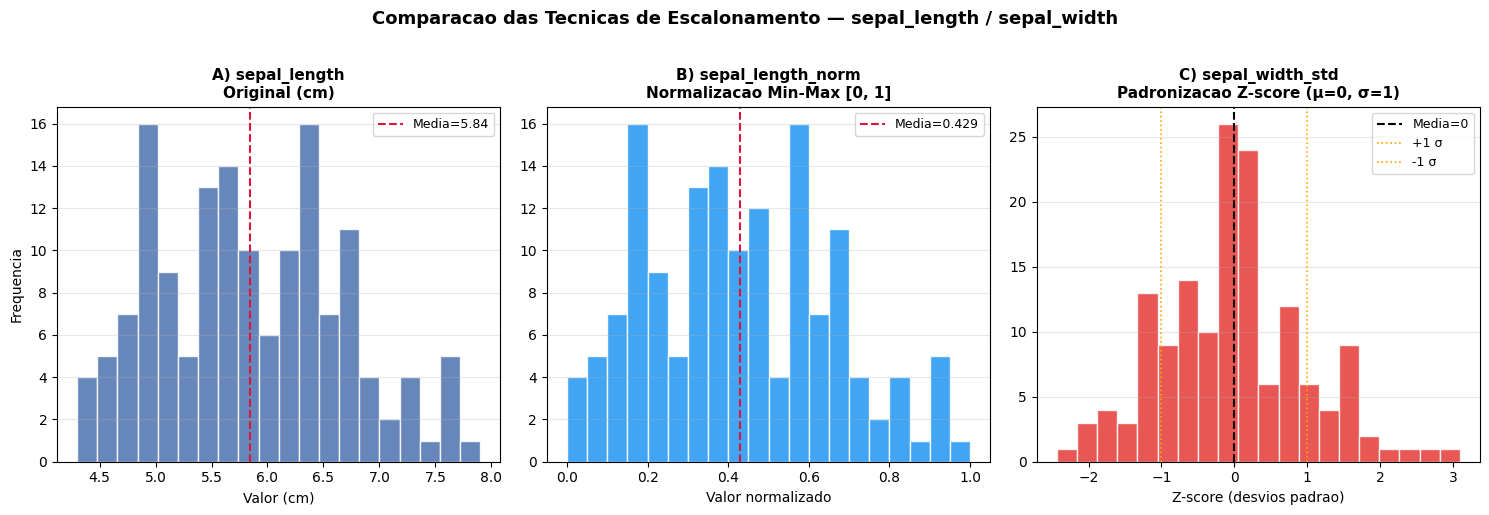

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original
ax = axes[0]
ax.hist(df['sepal_length'], bins=20, color='#4C72B0', edgecolor='white', alpha=0.85)
ax.set_title('A) sepal_length\nOriginal (cm)', fontsize=11, fontweight='bold')
ax.set_xlabel('Valor (cm)')
ax.set_ylabel('Frequencia')
ax.axvline(df['sepal_length'].mean(), color='crimson', linestyle='--', linewidth=1.5, label=f'Media={df["sepal_length"].mean():.2f}')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Min-Max
ax = axes[1]
ax.hist(df['sepal_length_norm'], bins=20, color='#2196F3', edgecolor='white', alpha=0.85)
ax.set_title('B) sepal_length_norm\nNormalizacao Min-Max [0, 1]', fontsize=11, fontweight='bold')
ax.set_xlabel('Valor normalizado')
ax.axvline(df['sepal_length_norm'].mean(), color='crimson', linestyle='--', linewidth=1.5, label=f'Media={df["sepal_length_norm"].mean():.3f}')
ax.legend(fontsize=9)
ax.set_xlim(-0.05, 1.05)
ax.grid(axis='y', alpha=0.3)

# Z-score
ax = axes[2]
ax.hist(df['sepal_width_std'], bins=20, color='#E53935', edgecolor='white', alpha=0.85)
ax.set_title('C) sepal_width_std\nPadronizacao Z-score (μ=0, σ=1)', fontsize=11, fontweight='bold')
ax.set_xlabel('Z-score (desvios padrao)')
ax.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Media=0')
ax.axvline(1, color='orange', linestyle=':', linewidth=1.2, label='+1 σ')
ax.axvline(-1, color='orange', linestyle=':', linewidth=1.2, label='-1 σ')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Comparacao das Tecnicas de Escalonamento — sepal_length / sepal_width',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6. Discretização — Transformando Variável Contínua em Categórica

A **discretização** converte uma variável numérica contínua em categorias (bins). Isso é útil para algoritmos que exigem atributos nominais, como regras de associação (Apriori) e alguns classificadores.

**Estratégias comuns:**
- **Equal-width (largura igual):** divide o intervalo [min, max] em k faixas de mesmo tamanho → `pd.cut`
- **Equal-frequency (frequência igual):** divide em k faixas com mesmo número de amostras → `pd.qcut`

In [11]:
# Discretizacao por largura igual (equal-width)
df['petal_length_cat'] = pd.cut(
    df['petal_length'],
    bins=3,
    labels=[0, 1, 2]   # 0 = pequena, 1 = media, 2 = grande
).astype(int)

# Discretizacao por frequencia igual (equal-frequency)
df['petal_width_qcat'] = pd.qcut(
    df['petal_width'],
    q=3,
    labels=[0, 1, 2]   # 0 = estreita, 1 = media, 2 = larga
).astype(int)

print('Distribuicao das categorias — petal_length_cat (equal-width):')
print(df['petal_length_cat'].value_counts().sort_index())
print('  0 = pequena | 1 = media | 2 = grande')

print()
print('Distribuicao das categorias — petal_width_qcat (equal-frequency):')
print(df['petal_width_qcat'].value_counts().sort_index())
print('  0 = estreita | 1 = media | 2 = larga')

print()
print('Primeiras 10 linhas com as colunas discretizadas:')
display(df[['petal_length', 'petal_length_cat', 'petal_width', 'petal_width_qcat', 'Especie']].head(10))

Distribuicao das categorias — petal_length_cat (equal-width):
petal_length_cat
0    50
1    54
2    46
Name: count, dtype: int64
  0 = pequena | 1 = media | 2 = grande

Distribuicao das categorias — petal_width_qcat (equal-frequency):
petal_width_qcat
0    50
1    52
2    48
Name: count, dtype: int64
  0 = estreita | 1 = media | 2 = larga

Primeiras 10 linhas com as colunas discretizadas:


,petal_length,petal_length_cat,petal_width,petal_width_qcat,Especie
0,1.4,0,0.2,0,Setosa
1,1.4,0,0.2,0,Setosa
2,1.3,0,0.2,0,Setosa
3,1.5,0,0.2,0,Setosa
4,1.4,0,0.2,0,Setosa
5,1.7,0,0.4,0,Setosa
6,1.4,0,0.3,0,Setosa
7,1.5,0,0.2,0,Setosa
8,1.4,0,0.2,0,Setosa
9,1.5,0,0.1,0,Setosa


In [12]:
# Exibindo os intervalos de cada bin para petal_length
_, bins_width = pd.cut(df['petal_length'], bins=3, retbins=True)
print('Intervalos da discretizacao equal-width (petal_length):')
for i, (lo, hi) in enumerate(zip(bins_width[:-1], bins_width[1:])):
    rotulo = ['Pequena (0)', 'Media (1)', 'Grande (2)'][i]
    print(f'  {rotulo}: ({lo:.2f}, {hi:.2f}] cm')

Intervalos da discretizacao equal-width (petal_length):
  Pequena (0): (0.99, 2.97] cm
  Media (1): (2.97, 4.93] cm
  Grande (2): (4.93, 6.90] cm


### 7. Visualização das Discretizações

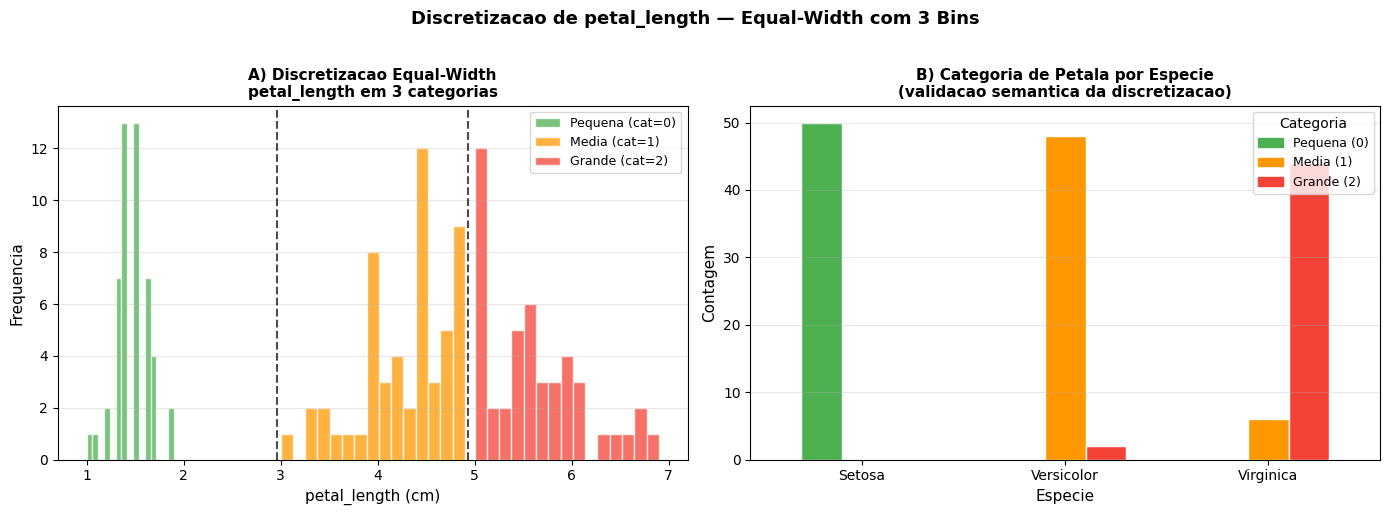

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cores_cat = {0: '#4CAF50', 1: '#FF9800', 2: '#F44336'}
rotulos_cat = {0: 'Pequena', 1: 'Media', 2: 'Grande'}

# Histograma colorido por categoria
ax = axes[0]
for cat in [0, 1, 2]:
    subset = df[df['petal_length_cat'] == cat]['petal_length']
    ax.hist(subset, bins=15, alpha=0.75, color=cores_cat[cat],
            edgecolor='white', label=f'{rotulos_cat[cat]} (cat={cat})')

_, bins_w = pd.cut(df['petal_length'], bins=3, retbins=True)
for b in bins_w[1:-1]:
    ax.axvline(b, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

ax.set_xlabel('petal_length (cm)', fontsize=11)
ax.set_ylabel('Frequencia', fontsize=11)
ax.set_title('A) Discretizacao Equal-Width\npetal_length em 3 categorias', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Contagem de categorias por especie
ax = axes[1]
tab = df.groupby(['Especie', 'petal_length_cat']).size().unstack(fill_value=0)
tab.plot(kind='bar', ax=ax, color=[cores_cat[c] for c in tab.columns],
         edgecolor='white', width=0.6)
ax.set_xlabel('Especie', fontsize=11)
ax.set_ylabel('Contagem', fontsize=11)
ax.set_title('B) Categoria de Petala por Especie\n(validacao semantica da discretizacao)', fontsize=11, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
handles = [plt.Rectangle((0,0),1,1, color=cores_cat[c]) for c in [0,1,2]]
ax.legend(handles, ['Pequena (0)', 'Media (1)', 'Grande (2)'], fontsize=9, title='Categoria')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Discretizacao de petal_length — Equal-Width com 3 Bins',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 8. Demonstração do Impacto de Outliers nas Técnicas de Normalização

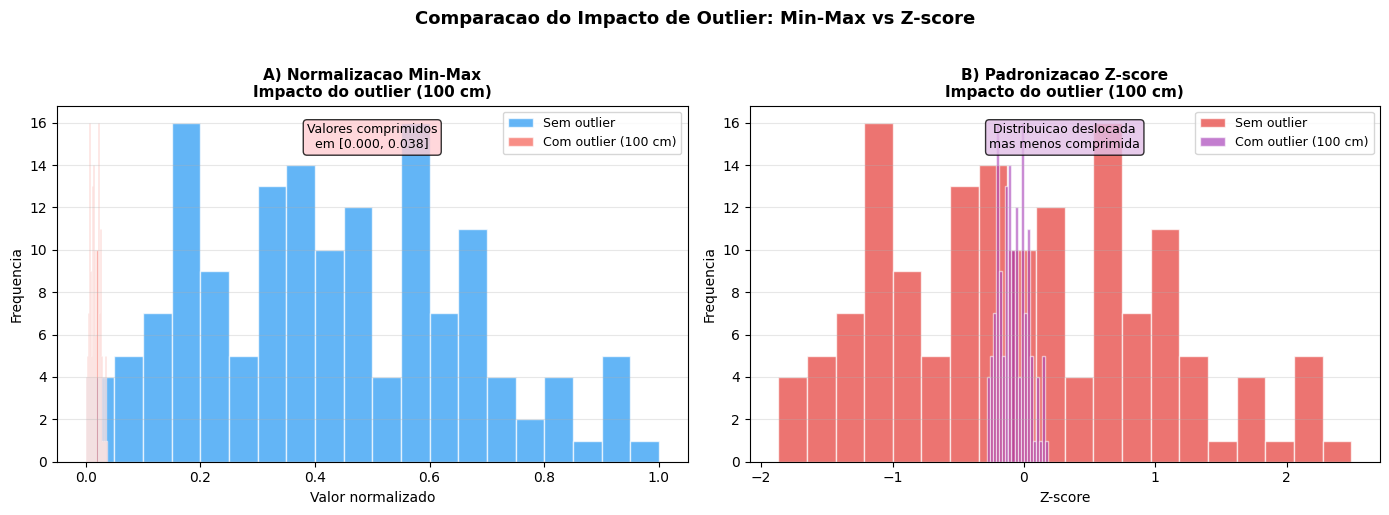

Min-Max SEM outlier : min=0.0000, max=1.0000
Min-Max COM outlier : min=0.0000,  max=0.0376
=> Todos os 150 valores normais foram comprimidos no intervalo [0.0000, 0.0376]!


In [14]:
# Simulando um outlier = flor com sepal_length = 100 cm
df_outlier = df[['sepal_length']].copy()
df_outlier_com = pd.concat([
    df_outlier,
    pd.DataFrame({'sepal_length': [100.0]})
], ignore_index=True)

# Min-Max com outlier
mm = MinMaxScaler()
norm_com_outlier = mm.fit_transform(df_outlier_com)[:-1]  # remove o outlier da visualizacao

# Z-score com outlier
ss = StandardScaler()
std_com_outlier = ss.fit_transform(df_outlier_com)[:-1]

# Comparacao
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(df['sepal_length_norm'], bins=20, alpha=0.7, color='#2196F3',
        edgecolor='white', label='Sem outlier')
ax.hist(norm_com_outlier, bins=20, alpha=0.6, color='#F44336',
        edgecolor='white', label='Com outlier (100 cm)')
ax.set_title('A) Normalizacao Min-Max\nImpacto do outlier (100 cm)', fontsize=11, fontweight='bold')
ax.set_xlabel('Valor normalizado')
ax.set_ylabel('Frequencia')
ax.legend(fontsize=9)
ax.set_xlim(-0.05, 1.05)
ax.grid(axis='y', alpha=0.3)
ax.text(0.5, 0.88,
        f'Valores comprimidos\nem [{norm_com_outlier.min():.3f}, {norm_com_outlier.max():.3f}]',
        transform=ax.transAxes, ha='center', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='#FFCDD2', alpha=0.8))

ax = axes[1]
ax.hist(df['sepal_length_std'], bins=20, alpha=0.7, color='#E53935',
        edgecolor='white', label='Sem outlier')
ax.hist(std_com_outlier, bins=20, alpha=0.6, color='#9C27B0',
        edgecolor='white', label='Com outlier (100 cm)')
ax.set_title('B) Padronizacao Z-score\nImpacto do outlier (100 cm)', fontsize=11, fontweight='bold')
ax.set_xlabel('Z-score')
ax.set_ylabel('Frequencia')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.text(0.5, 0.88,
        f'Distribuicao deslocada\nmas menos comprimida',
        transform=ax.transAxes, ha='center', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='#E1BEE7', alpha=0.8))

plt.suptitle('Comparacao do Impacto de Outlier: Min-Max vs Z-score',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Min-Max SEM outlier : min={df["sepal_length_norm"].min():.4f}, max={df["sepal_length_norm"].max():.4f}')
print(f'Min-Max COM outlier : min={norm_com_outlier.min():.4f},  max={norm_com_outlier.max():.4f}')
print(f'=> Todos os 150 valores normais foram comprimidos no intervalo [{norm_com_outlier.min():.4f}, {norm_com_outlier.max():.4f}]!')

### 9. Dataset Final Pré-Processado

In [15]:
colunas_finais = [
    'sepal_length', 'sepal_length_norm', 'sepal_length_std',
    'sepal_width',  'sepal_width_norm',  'sepal_width_std',
    'petal_length', 'petal_length_norm', 'petal_length_std', 'petal_length_cat',
    'petal_width',  'petal_width_norm',  'petal_width_std',  'petal_width_qcat',
    'Especie'
]

print('Dataset apos pre-processamento completo (primeiras 10 linhas):')
display(df[colunas_finais].head(10).round(4))

print('\nResumo das colunas criadas:')
resumo = pd.DataFrame({
    'Coluna': [
        'sepal_length_norm', 'sepal_width_norm', 'petal_length_norm', 'petal_width_norm',
        'sepal_length_std',  'sepal_width_std',  'petal_length_std',  'petal_width_std',
        'petal_length_cat',  'petal_width_qcat'
    ],
    'Tecnica': [
        'Min-Max', 'Min-Max', 'Min-Max', 'Min-Max',
        'Z-score', 'Z-score', 'Z-score', 'Z-score',
        'Equal-Width (3 bins)', 'Equal-Freq (3 quantis)'
    ],
    'Intervalo esperado': [
        '[0, 1]', '[0, 1]', '[0, 1]', '[0, 1]',
        '(-∞, +∞), μ=0 σ=1', '(-∞, +∞), μ=0 σ=1',
        '(-∞, +∞), μ=0 σ=1', '(-∞, +∞), μ=0 σ=1',
        '{0, 1, 2}', '{0, 1, 2}'
    ]
})
display(resumo)

Dataset apos pre-processamento completo (primeiras 10 linhas):


,sepal_length,sepal_length_norm,sepal_length_std,sepal_width,sepal_width_norm,sepal_width_std,petal_length,petal_length_norm,petal_length_std,petal_length_cat,petal_width,petal_width_norm,petal_width_std,petal_width_qcat,Especie
0,5.1,0.2222,-0.9007,3.5,0.6250,1.0190,1.4,0.0678,-1.3402,0,0.2,0.0417,-1.3154,0,Setosa
1,4.9,0.1667,-1.1430,3.0,0.4167,-0.1320,1.4,0.0678,-1.3402,0,0.2,0.0417,-1.3154,0,Setosa
2,4.7,0.1111,-1.3854,3.2,0.5000,0.3284,1.3,0.0508,-1.3971,0,0.2,0.0417,-1.3154,0,Setosa
3,4.6,0.0833,-1.5065,3.1,0.4583,0.0982,1.5,0.0847,-1.2834,0,0.2,0.0417,-1.3154,0,Setosa
4,5.0,0.1944,-1.0218,3.6,0.6667,1.2492,1.4,0.0678,-1.3402,0,0.2,0.0417,-1.3154,0,Setosa
5,5.4,0.3056,-0.5372,3.9,0.7917,1.9398,1.7,0.1186,-1.1697,0,0.4,0.1250,-1.0522,0,Setosa
6,4.6,0.0833,-1.5065,3.4,0.5833,0.7888,1.4,0.0678,-1.3402,0,0.3,0.0833,-1.1838,0,Setosa
7,5.0,0.1944,-1.0218,3.4,0.5833,0.7888,1.5,0.0847,-1.2834,0,0.2,0.0417,-1.3154,0,Setosa
8,4.4,0.0278,-1.7489,2.9,0.3750,-0.3622,1.4,0.0678,-1.3402,0,0.2,0.0417,-1.3154,0,Setosa
9,4.9,0.1667,-1.1430,3.1,0.4583,0.0982,1.5,0.0847,-1.2834,0,0.1,0.0000,-1.4471,0,Setosa



Resumo das colunas criadas:


,Coluna,Tecnica,Intervalo esperado
0,sepal_length_norm,Min-Max,"[0, 1]"
1,sepal_width_norm,Min-Max,"[0, 1]"
2,petal_length_norm,Min-Max,"[0, 1]"
3,petal_width_norm,Min-Max,"[0, 1]"
4,sepal_length_std,Z-score,"(-∞, +∞), μ=0 σ=1"
5,sepal_width_std,Z-score,"(-∞, +∞), μ=0 σ=1"
6,petal_length_std,Z-score,"(-∞, +∞), μ=0 σ=1"
7,petal_width_std,Z-score,"(-∞, +∞), μ=0 σ=1"
8,petal_length_cat,Equal-Width (3 bins),"{0, 1, 2}"
9,petal_width_qcat,Equal-Freq (3 quantis),"{0, 1, 2}"


### 10. Painel Comparativo Final — Todas as Transformações

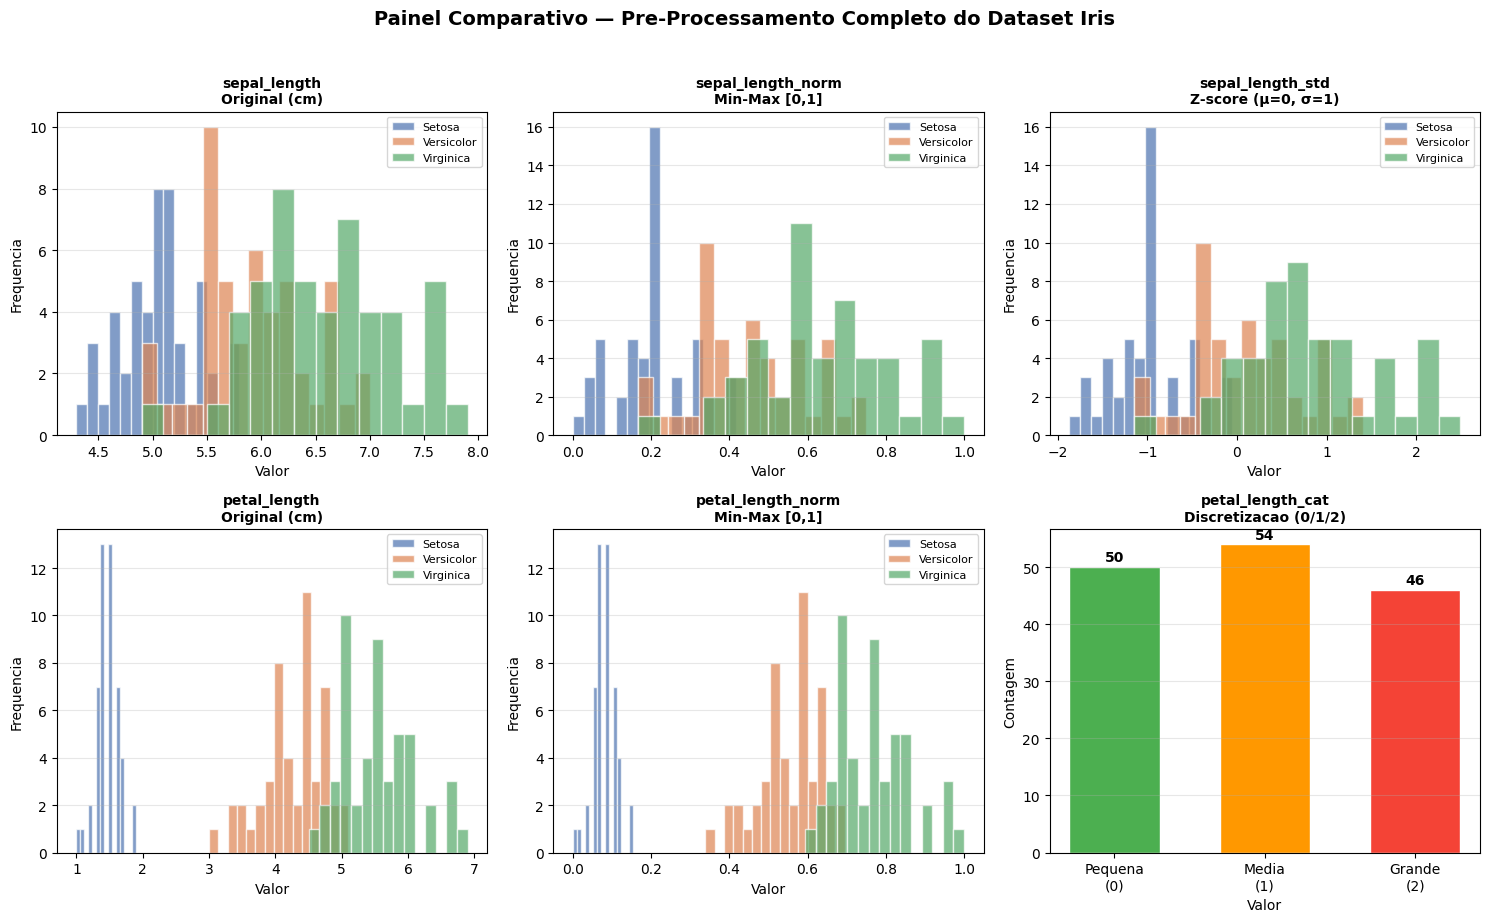

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

paleta = {'Setosa': '#4C72B0', 'Versicolor': '#DD8452', 'Virginica': '#55A868'}

# sepal_length: original, norm, std
for ax, col, titulo in zip(
    axes[0],
    ['sepal_length', 'sepal_length_norm', 'sepal_length_std'],
    ['sepal_length\nOriginal (cm)', 'sepal_length_norm\nMin-Max [0,1]', 'sepal_length_std\nZ-score (μ=0, σ=1)']
):
    for esp, cor in paleta.items():
        ax.hist(df[df['Especie'] == esp][col], bins=15, alpha=0.7,
                color=cor, edgecolor='white', label=esp)
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frequencia')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

# Lpetal_length: original, norm, cat
for ax, col, titulo in zip(
    axes[1],
    ['petal_length', 'petal_length_norm', 'petal_length_cat'],
    ['petal_length\nOriginal (cm)', 'petal_length_norm\nMin-Max [0,1]', 'petal_length_cat\nDiscretizacao (0/1/2)']
):
    if col == 'petal_length_cat':
        cores_cat_esp = {0: '#4CAF50', 1: '#FF9800', 2: '#F44336'}
        counts = df[col].value_counts().sort_index()
        bars = ax.bar(counts.index, counts.values,
                      color=[cores_cat_esp[c] for c in counts.index],
                      edgecolor='white', width=0.6)
        for bar, val in zip(bars, counts.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    str(val), ha='center', fontsize=10, fontweight='bold')
        ax.set_xticks([0, 1, 2])
        ax.set_xticklabels(['Pequena\n(0)', 'Media\n(1)', 'Grande\n(2)'])
        ax.set_ylabel('Contagem')
    else:
        for esp, cor in paleta.items():
            ax.hist(df[df['Especie'] == esp][col], bins=15, alpha=0.7,
                    color=cor, edgecolor='white', label=esp)
        ax.legend(fontsize=8)
        ax.set_ylabel('Frequencia')
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Painel Comparativo — Pre-Processamento Completo do Dataset Iris',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 11. Respostas às Questões de Fixação

---

#### Questão 1 — Normalização vs. Transformação: Qual técnica garante valores estritamente entre 0 e 1? Quando usar z-score?

A coluna **`sepal_length_norm` (Min-Max)** é a que garante valores **estritamente no intervalo [0, 1]**, por construção da fórmula:

$$x_{\text{norm}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

O menor valor da amostra sempre se torna exatamente 0 e o maior exatamente 1. Conforme a tabela de `describe()` da Seção 3, `min = 0.0000` e `max = 1.0000` em todas as colunas normalizadas.

A coluna **`sepal_width_std` (z-score)**, por outro lado, produz média 0 e desvio padrão 1, mas os valores **ultrapassam o intervalo [0, 1]** (incluem negativos e valores maiores que 1). Isso é confirmado pelo gráfico C da Seção 5.

| Técnica | Intervalo garantido | Média | Desvio Padrão |
|---|---|---|---|
| Min-Max | **[0, 1] exato** | variável | variável |
| Z-score | (-∞, +∞) | **≈ 0** | **≈ 1** |

**Quando preferir z-score:** quando os dados possuem uma distribuição aproximadamente gaussiana (normal), quando se quer preservar a estrutura de outliers sem destruir a variância relativa, ou em algoritmos sensíveis à distribuição, como PCA, SVM e redes neurais. A padronização z-score é preferível quando os dados têm outliers significativos, pois não é distorcida pelos valores extremos da mesma forma que o Min-Max.

---

#### Questão 2 — Discretização: O que representam os valores 0, 1 e 2 em `petal_length_cat`?

Os valores 0, 1 e 2 são **rótulos numéricos das categorias** criadas pela divisão do intervalo de `petal_length` em 3 faixas de igual largura:

| Rótulo | Categoria | Intervalo (cm) | Espécie predominante |
|---|---|---|---|
| **0** | Pétala **Pequena** | aprox. (0.99, 3.30] | Setosa |
| **1** | Pétala **Média** | aprox. (3.30, 5.60] | Versicolor |
| **2** | Pétala **Grande** | aprox. (5.60, 6.90] | Virginica |

Como o gráfico B da Seção 7 demonstra, essa simplificação possui **coerência biológica**: a *Setosa* tem pétalas quase exclusivamente pequenas (categoria 0), a *Versicolor* tem pétalas médias (categoria 1) e a *Virginica* tem pétalas grandes (categoria 2).

**Por que isso ajuda o especialista de domínio?** Um biólogo ou agrônomo pode validar intuitivamente se a faixa de "pétalas pequenas" faz sentido botânico, identificar erros de medição que caíram na categoria errada, e comunicar descobertas sem precisar lidar com centenas de valores contínuos. Algoritmos de regras de associação como o Apriori trabalham diretamente com esses rótulos discretos, gerando regras do tipo: *"SE petal_length_cat = 0 ENTÃO Espécie = Setosa"*.

---

#### Questão 3 — Impacto de Outliers: Qual técnica sofreria mais com uma sépala de 100 cm?

A **Normalização Min-Max** sofreria o maior impacto negativo, conforme demonstrado na Seção 8.

**Por quê?** A fórmula depende diretamente do valor **máximo** da amostra:

$$x_{\text{norm}} = \frac{x - x_{\min}}{\underbrace{x_{\max}}_{\text{agora = 100}} - x_{\min}}$$

Com o outlier de 100 cm, o denominador salta de ~3,6 cm para ~95,6 cm. Todos os 150 valores normais — que iam de 0 a 1 — ficam comprimidos em uma faixa minúscula próxima de 0 (conforme mostrado no Painel A da Seção 8). A informação discriminativa entre as flores normais praticamente desaparece.

Já o **Z-score** é perturbado pelo outlier, mas de forma menos severa: ele desloca a média e infla o desvio padrão, mas preserva melhor as distâncias relativas entre os pontos normais. Técnicas ainda mais robustas — como a **Normalização por Intervalo Interquartil (IQR):**

$$x_{\text{robust}} = \frac{x - Q_1}{Q_3 - Q_1}$$

...são imunes a esse problema porque $Q_1$ e $Q_3$ não se alteram com um único ponto extremo.

| Técnica | Fórmula depende de | Sensibilidade a outliers |
|---|---|---|
| **Min-Max** | min, **max** | **Muito alta** |
| **Z-score** | média, desvio padrão | Moderada |
| **IQR (Robust Scaler)** | Q1, Q3 | Baixa |